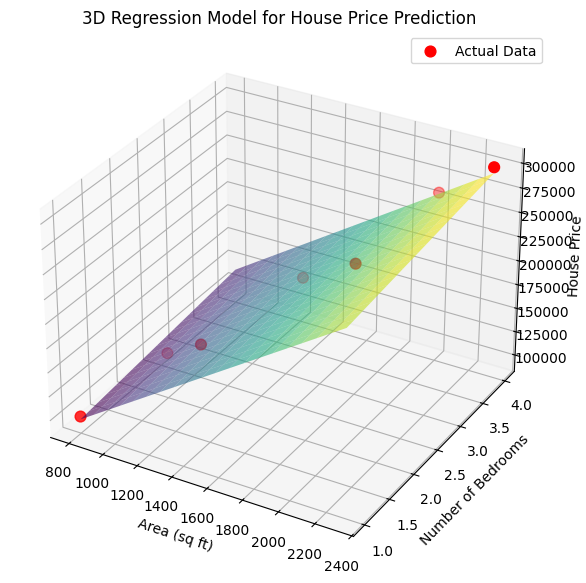

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.linear_model import LinearRegression

area = np.array([800, 1000, 1200, 1500, 1800, 2000, 2300])
bedrooms = np.array([1, 2, 2, 3, 3, 4, 4])
price = np.array([100000, 130000, 150000, 190000, 220000, 260000, 300000])

X = np.column_stack((area, bedrooms))
y = price

model = LinearRegression()
model.fit(X, y)

area_grid, bedroom_grid = np.meshgrid(
    np.linspace(area.min(), area.max(), 20),
    np.linspace(bedrooms.min(), bedrooms.max(), 20)
)

price_grid = model.predict(
    np.column_stack((area_grid.ravel(), bedroom_grid.ravel()))
).reshape(area_grid.shape)

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot of actual data
ax.scatter(area, bedrooms, price, color='red', s=60, label='Actual Data')

# Regression surface
ax.plot_surface(area_grid, bedroom_grid, price_grid,
                alpha=0.6, cmap='viridis')

# Labels
ax.set_xlabel('Area (sq ft)')
ax.set_ylabel('Number of Bedrooms')
ax.set_zlabel('House Price')
ax.set_title('3D Regression Model for House Price Prediction')

ax.legend()
plt.show()

